# VayuNetra Ops — detect → verify → quantify → act on Indian landfill methane
Uses the fine-tuned VayuNetra model exported from the training notebook (Cell 30 zip). No training data needed.

**Flow:** load model → scan landfills + control sites with Sentinel-2 (Earth Engine) → physics gate → evidence tiers →
emission rate with uncertainty → per-site detection limit → action dossiers (fix options, CO₂e, energy, value) →
hyperspectral tasking list → map → monitoring → zip.

**Cell 1 — Install.** Adds Earth Engine, map and model libraries if missing.
Everything else (numpy, torch, matplotlib) is assumed present on a GPU/Colab image.

In [1]:
import subprocess, sys, importlib.util
for mod, pkg in [("ee", "earthengine-api"), ("pyproj", "pyproj"), ("segmentation_models_pytorch", "segmentation-models-pytorch"),
                 ("timm", "timm"), ("folium", "folium"), ("scipy", "scipy")]:
    if importlib.util.find_spec(mod) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

**Cell 2 — Config.** Where the exported model is, your Earth Engine project, the scan window, the landfill list and the economic assumptions.
Add landfills by editing `SITES` or pointing `SITES_CSV` at a file with columns `name,lat,lon,elev`.

In [23]:
import os, io, json, math, time, base64, zipfile, hashlib, shutil, warnings, datetime as dt
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, gaussian_filter
from scipy.stats import fisher_exact
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

EXPORT      = os.environ.get("VAYU_EXPORT", "vayunetra_best")      # folder or .zip from training-notebook Cell 30
GEE_PROJECT = os.environ.get("VAYU_GEE_PROJECT", "gen-lang-client-0706669487")
OFFLINE     = bool(int(os.environ.get("VAYU_OFFLINE", "0")))      # synthetic scenes: tests the notebook without Earth Engine
OUT         = Path(os.environ.get("VAYU_OPS_OUT", "vayunetra_ops")); OUT.mkdir(parents=True, exist_ok=True)
CHIP_DIR    = Path(os.environ.get("VAYU_CHIP_DIR", OUT / "chips")); CHIP_DIR.mkdir(parents=True, exist_ok=True)   # point at the training run's india_chips folder to skip re-downloading

START, END = "2024-01-01", "2025-12-31"          # scan window (references may come from up to 150 days around each pass)
MAX_CLOUD, N_REF, MAX_PASSES = 30, 4, int(os.environ.get("VAYU_MAX_PASSES", 80))
REF_MIN_DAYS, REF_MAX_DAYS = 10, 150
CONTROL_OFFSET_DEG = 0.045                        # control site ≈5 km north of each landfill (check the printed Maps link)

SITES = {                                         # name: (lat, lon, elevation m, city)
    "Ghazipur":  (28.6247, 77.3272, 210, "Delhi"),
    "Bhalswa":   (28.7406, 77.1582, 215, "Delhi"),
    "Okhla":     (28.5125, 77.2835, 205, "Delhi"),
    "Deonar":    (19.0717, 72.9278, 10,  "Mumbai"),
    "Pirana":    (22.9762, 72.5656, 50,  "Ahmedabad"),
}
SITES_CSV = os.environ.get("VAYU_SITES_CSV")
if SITES_CSV and Path(SITES_CSV).exists():
    for _, r in pd.read_csv(SITES_CSV).iterrows():
        SITES[str(r["name"])] = (float(r["lat"]), float(r["lon"]), float(r.get("elev", 100)), str(r.get("city", "")))

# Economic / physical assumptions — edit to match your case; every dossier prints the values used.
ASSUME = dict(
    gwp100=27.0, gwp20=79.7,            # IPCC AR6, non-fossil (biogenic) CH4
    capture_eff=0.60,                   # share of emitted CH4 a gas collection system captures
    flare_destruction=0.98,             # CH4 destroyed by an enclosed flare / engine
    ch4_lhv_mj_per_kg=50.0,             # lower heating value of methane
    engine_eff=0.35,                    # landfill-gas engine electrical efficiency
    power_price_inr_per_kwh=5.0,        # tariff assumption
    carbon_price_usd_per_t=10.0,        # voluntary carbon credit assumption
    wind_rel_unc=0.30,                  # 1-sigma relative uncertainty of ERA5 10 m wind
    calib_rel_unc=0.20,                 # 1-sigma relative uncertainty of the IME wind calibration
)
INCLUDE_T2_IN_ANNUAL = False            # conservative: annual figures use methane-confident (T1) events only
print(f"OUT={OUT.resolve()} | offline={OFFLINE} | sites={list(SITES)}")

OUT=/workspace/vayunetra_ops | offline=False | sites=['Ghazipur', 'Bhalswa', 'Okhla', 'Deonar', 'Pirana']


**Cell 3 — Load the VayuNetra model.** Unzips the export, checks the SHA256, rebuilds the U-Net and loads the fine-tuned weights plus its threshold and emission calibration.
The model card is the single source of truth: inputs, threshold and physics rules all come from it.

In [24]:
# Cell 3 — Load the VayuNetra model from the export zip in this folder
import torch, segmentation_models_pytorch as smp
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP = DEVICE == "cuda"
AMP_DTYPE = torch.bfloat16 if (AMP and torch.cuda.is_bf16_supported()) else torch.float16

def find_model_zip():
    if str(EXPORT).endswith(".zip") and Path(EXPORT).exists(): return Path(EXPORT)
    zips = sorted(Path.cwd().glob("*.zip"), key=lambda p: (not p.name.startswith("vayunetra_best_model_"), -p.stat().st_mtime))
    for z in zips:
        try: names = zipfile.ZipFile(z).namelist()
        except zipfile.BadZipFile: continue
        if any(n.endswith(("model_card.json", "vayunetra_config.json")) for n in names) and any(n.endswith(".pt") for n in names): return z
    raise FileNotFoundError(f"no model zip in {Path.cwd()} — zips seen: {[z.name for z in zips]}")

ZIP = find_model_zip(); print("using:", ZIP.name)
MROOT = OUT / "model"; shutil.rmtree(MROOT, ignore_errors=True); zipfile.ZipFile(ZIP).extractall(MROOT)
card_path = next(iter(MROOT.rglob("model_card.json")), None) or next(MROOT.rglob("vayunetra_config.json"))
MDIR, CARD = card_path.parent, json.load(open(card_path))
WPATH = next((p for w in ["vayunetra_best.pt", "best.pt", "vayunetra_ssl4eo_unet.pt"] for p in MROOT.rglob(w)), None)
assert WPATH is not None, f"no weights inside {ZIP.name}"
sha_file = next(iter(MROOT.rglob("SHA256.txt")), None)
if sha_file and WPATH.name == "vayunetra_best.pt":
    assert hashlib.sha256(open(WPATH, "rb").read()).hexdigest() == sha_file.read_text().split()[0], "weights checksum mismatch"
LUT_PATH = next(iter(MROOT.rglob("integrated_transmittances.json")), None)
assert LUT_PATH is not None, "integrated_transmittances.json missing from the zip"

IN_CH = int(CARD.get("in_channels", 17)); N_EXTRA = IN_CH - 13
CHIP, PAD = int(CARD.get("chip", 200)), int(CARD.get("pad", 12))
MIN_PLUME_PX = int(CARD.get("min_plume_px", 20)); PIX_M = 10.0
THR = float(os.environ.get("VAYU_THR", CARD["scene_threshold"]))
A_CAL, B_CAL = float(CARD["ime"]["a"]), float(CARD["ime"]["b"])

model = smp.Unet("resnet50", encoder_weights=None, in_channels=IN_CH, classes=1,
                 decoder_attention_type="scse", aux_params=dict(classes=1, pooling="avg", dropout=0.2))
sd = torch.load(WPATH, map_location="cpu"); sd = sd.get("state_dict", sd)
model.load_state_dict({k: v.float() for k, v in sd.items()}); model = model.to(DEVICE).eval()
if DEVICE == "cuda": model = model.to(memory_format=torch.channels_last)
print(f"model {WPATH.name} on {DEVICE} | in_ch {IN_CH} | threshold {THR:.3f} | U_eff = {A_CAL:.3f}·U10 + {B_CAL:.3f}")
if "test_metrics" in CARD: print("test metrics:", json.dumps(CARD["test_metrics"])[:300])

using: vayunetra_best_model_20261001_1401.zip
model vayunetra_best.pt on cuda | in_ch 17 | threshold 0.844 | U_eff = 0.140·U10 + 1.111
test metrics: {"VayuNetra (SSL4EO U-Net)": {"precision": 0.779, "recall": 0.303, "fpr": 0.086, "pixel IoU": 0.312}, "MBMP baseline": {"precision": 0.602, "recall": 0.144, "fpr": 0.096, "pixel IoU": 0.077}}


**Cell 4 — Methane physics + inference core.** The same MBMP retrieval, transmittance forward model, input stack and 4-flip inference used in training, plus emission rate (IME) and the physics gate.
Physics gate: methane dims B12 strongly, B11 weakly and visible/NIR not at all, and plumes stretch along the wind; landfill fires, moisture and dumping fail it.

In [25]:
LUT = json.load(open(LUT_PATH))
AMF_ARR, MR, BGPPB = np.array(LUT["amf_arr"]), np.array(LUT["mr_ch4_arr"]), float(LUT["background_concentration"])
LUT_KEYS = [k for k in LUT if isinstance(LUT[k], dict)]
B = dict(blue=1, green=2, red=3, nir=8, swir1=11, swir2=12)        # 0-based, L1C order B1..B8,B8A,B9..B12
S2_BANDS = ["B1", "B2", "B3", "B4", "B5", "B6", "B7", "B8", "B8A", "B9", "B10", "B11", "B12"]
M_CH4, G, M_AIR = 0.01604, 9.81, 0.028964

def lut_key(sensor): s = str(sensor).upper(); return next((k for k in LUT_KEYS if k in s), "S2A")
def amf_of(sza, vza=0.0): return float(np.clip(1 / np.cos(np.radians(sza)) + 1 / np.cos(np.radians(vza)), AMF_ARR.min(), AMF_ARR.max()))
def band_ratios(enh_ppb, key, amf):
    i = int(np.argmin(np.abs(AMF_ARR - amf))); mr = MR[i]
    t11, t12 = np.array(LUT[key]["transmittance_b11"][i]), np.array(LUT[key]["transmittance_b12"][i]); x = BGPPB + enh_ppb
    return np.interp(x, mr, t11) / np.interp(BGPPB, mr, t11), np.interp(x, mr, t12) / np.interp(BGPPB, mr, t12)
def mbsp(r11, r12, v):
    a, b = r11[v], r12[v]; c = float((a * b).sum() / max((b * b).sum(), 1e-12))
    return (c * r12 - r11) / np.maximum(r11, 1e-6)
def mbmp(t11, t12, refs):
    v = (t11 > 0) & (t12 > 0); st = mbsp(t11, t12, v)
    m = np.nanmedian(np.stack([mbsp(r11, r12, v & (r11 > 0) & (r12 > 0)) - st for r11, r12 in refs]), 0)
    m[~v] = 0; return np.nan_to_num(m).astype("float32")
def robust_sigma(x): x = x[np.isfinite(x)]; return float(1.4826 * np.median(np.abs(x - np.median(x)))) + 1e-6
def make_input(img13, refs, m):
    ref = np.median(np.stack([np.stack(r) for r in refs]), 0)
    extra = [ref[0], ref[1], np.clip(m / 0.02, -10, 10), np.clip((m - np.median(m)) / robust_sigma(m), -8, 8)]
    return np.concatenate([np.clip(img13, 0, 2), np.stack(extra)]).astype("float32")

@torch.no_grad()
def predict(x):
    xx = torch.from_numpy(np.pad(x, ((0, 0), (PAD, PAD), (PAD, PAD)), mode="reflect"))[None].to(DEVICE)
    if DEVICE == "cuda": xx = xx.to(memory_format=torch.channels_last)
    ps = []
    for fl in [(), (2,), (3,), (2, 3)]:
        with torch.autocast("cuda", dtype=AMP_DTYPE, enabled=AMP):
            s, _ = model(torch.flip(xx, fl) if fl else xx)
        s = torch.sigmoid(s.float()); ps.append(torch.flip(s, fl) if fl else s)
    p = torch.stack(ps).mean(0)[0, 0, PAD:-PAD, PAD:-PAD]
    flat = p.reshape(-1); score = float(torch.topk(flat, min(MIN_PLUME_PX, flat.numel())).values.mean())
    return p.cpu().numpy(), score

def ppb_from_mbmp(m, key, amf):
    dd = np.linspace(0, 8000, 401); r11, r12 = band_ratios(dd, key, amf); s = 1 - r12 / r11; slope0 = (s[1] - s[0]) / (dd[1] - dd[0])
    return np.where(m >= 0, np.interp(m, s, dd), m / slope0)
def n_air(elev): return 101325 * math.exp(-elev / 8434.0) / (G * M_AIR)          # mol air per m² column
def ime_kg(m, mask, key, amf, elev):
    return float((ppb_from_mbmp(m, key, amf)[mask] * 1e-9 * n_air(elev) * M_CH4).sum() * PIX_M ** 2), math.sqrt(mask.sum() * PIX_M ** 2)

def band_change(tgt, ref, msk, ring):
    r = tgt / np.clip(ref, 1e-4, None) - 1
    return float(np.median(r[msk]) - np.median(r[ring]))
def physics_check(tgt, ref_chips, prob, u, v):
    """Methane: B12 dims >1%, B11 < half of B12, visible/NIR < half of B12; elongated plumes within 45° of the wind."""
    ref = np.median(np.stack(ref_chips), 0); msk = prob > 0.5
    if msk.sum() < MIN_PLUME_PX: return dict(dB12=np.nan, dB11=np.nan, dVisNIR=np.nan, spectral_ok=False, elong=np.nan, axis_vs_wind=np.nan, aligned=False)
    ring = binary_dilation(msk, iterations=15) & ~binary_dilation(msk, iterations=3)
    if ring.sum() < 50: ring = ~msk
    if ring.sum() < 50: ring = np.ones_like(msk)
    d = {b: band_change(tgt[i], ref[i], msk, ring) for b, i in [("B2", 1), ("B4", 3), ("B8", 7), ("B11", 11), ("B12", 12)]}
    vis = max(abs(d["B2"]), abs(d["B4"]), abs(d["B8"]))
    spectral_ok = d["B12"] < -0.01 and vis < 0.5 * abs(d["B12"]) and d["B11"] > 0.5 * d["B12"]
    rr, cc = np.nonzero(msk); X = np.stack([cc - cc.mean(), -(rr - rr.mean())]).astype(float)
    w, V = np.linalg.eigh(np.cov(X)); elong = math.sqrt(w[1] / max(w[0], 1e-6))
    ok_wind = np.isfinite(u) and math.hypot(u, v) > 0
    axis = math.degrees(math.acos(min(1, abs(V[0, 1] * u + V[1, 1] * v) / (math.hypot(u, v) + 1e-9)))) if ok_wind else np.nan
    aligned = bool(elong < 2.0 or (ok_wind and axis <= 45))
    return dict(dB12=round(d["B12"], 4), dB11=round(d["B11"], 4), dVisNIR=round(vis, 4), spectral_ok=bool(spectral_ok),
                elong=round(elong, 1), axis_vs_wind=round(axis) if ok_wind else np.nan, aligned=aligned)
def geometry_check(prob, u, v, max_src_m=500, max_angle=60):
    m = prob > 0.5
    if m.sum() < MIN_PLUME_PX or not np.isfinite(u): return dict(src_dist_m=np.nan, wind_angle=np.nan, at_source_downwind=False)
    rr, cc = np.nonzero(m); c0 = CHIP / 2
    src = float(np.sqrt((rr - c0) ** 2 + (cc - c0) ** 2).min() * PIX_M)
    dx, dy = (cc.mean() - c0) * PIX_M, -(rr.mean() - c0) * PIX_M
    ang = float(np.degrees(np.arccos(np.clip((dx * u + dy * v) / (math.hypot(dx, dy) * math.hypot(u, v) + 1e-9), -1, 1))))
    return dict(src_dist_m=round(src), wind_angle=round(ang), at_source_downwind=bool(src <= max_src_m and ang <= max_angle))

def tier_of(r):
    """T1 methane-confident · T2 probable (near-miss on one test) · T3 surface change · '-' no detection."""
    if not r["detected"]: return "-"
    if r["spectral_ok"] and r["aligned"]: return "T1"
    d12, d11, vis = r["dB12"], r["dB11"], r["dVisNIR"]
    near = np.isfinite(d12) and d12 < -0.01 and vis < 0.7 * abs(d12) and d11 > 0.6 * d12
    if near and (r["aligned"] or r["at_source_downwind"]): return "T2"
    return "T3"
def surface_kind(r):
    """What a rejected (T3) event most likely is — useful landfill-management information in itself."""
    if r["tier"] != "T3" or not np.isfinite(r["dB12"]): return ""
    if r["dB12"] < -0.05 and r["dVisNIR"] > 0.04: return "burn scar / smoke-like"
    if r["dB12"] > 0: return "brightening (fresh waste / drying / earthworks)"
    return "SWIR darkening (moisture / leachate / fresh cover)"
print("physics core ready | LUT sensors:", LUT_KEYS)

physics core ready | LUT sensors: ['S2A', 'S2B', 'S2C', 'LC08', 'LC09', 'LE07', 'LT04', 'LT05']


**Cell 5 — Sentinel-2 + wind access.** Earth Engine helpers: list cloud-light passes, download 2 km chips (cached on disk) and fetch ERA5-Land 10 m wind at overpass time.
`OFFLINE=1` swaps in synthetic scenes so the whole notebook can be tested without an Earth Engine account.

In [26]:
if not OFFLINE:
    import ee
    from pyproj import Transformer
    try: ee.Initialize(project=GEE_PROJECT)
    except Exception: ee.Authenticate(auth_mode="notebook"); ee.Initialize(project=GEE_PROJECT)
HALF = CHIP * 10 // 2

def grid(lat, lon):
    epsg = (32600 if lat >= 0 else 32700) + int((lon + 180) // 6) + 1
    x, y = Transformer.from_crs("EPSG:4326", f"EPSG:{epsg}", always_xy=True).transform(lon, lat)
    return {"dimensions": {"width": CHIP, "height": CHIP}, "crsCode": f"EPSG:{epsg}",
            "affineTransform": {"scaleX": 10, "shearX": 0, "translateX": x - HALF, "shearY": 0, "scaleY": -10, "translateY": y + HALF}}

def _synthetic_chip(seed):
    """OFFLINE only: smooth 13-band surface with per-pass noise (stands in for Sentinel-2 TOA reflectance)."""
    rs = np.random.default_rng(seed); base = gaussian_filter(np.random.default_rng(seed // 1000).normal(size=(CHIP, CHIP)), 6)
    base = (base - base.min()) / (np.ptp(base) + 1e-9); lvl = np.linspace(0.08, 0.30, 13)
    x = np.stack([l * (0.7 + 0.6 * base) for l in lvl]) * (1 + rs.normal(0, 0.01)) + rs.normal(0, 0.002, (13, CHIP, CHIP))
    x[10] = 0.002 + rs.normal(0, 0.0005, (CHIP, CHIP)); return np.clip(x, 1e-4, None).astype("float32")

def list_passes(lat, lon, start=START, end=END):
    if OFFLINE:
        days = pd.date_range(start, end, freq="5D"); seed0 = int(abs(lat * 1e4 + lon * 1e2)) * 1000
        return pd.DataFrame(dict(idx=[f"SYN_{seed0 + k}" for k in range(len(days))], t=((days - pd.Timestamp("1970-01-01")) // pd.Timedelta("1ms")).astype("int64") + 5 * 3600 * 1000,
                                 sat=["Sentinel-2A"] * len(days), sza=np.random.default_rng(seed0).uniform(25, 50, len(days)), vza=5.0))
    lst = (ee.ImageCollection("COPERNICUS/S2_HARMONIZED").filterBounds(ee.Geometry.Point(lon, lat)).filterDate(start, end)
           .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", MAX_CLOUD))
           .reduceColumns(ee.Reducer.toList(5), ["system:index", "system:time_start", "SPACECRAFT_NAME",
                                                 "MEAN_SOLAR_ZENITH_ANGLE", "MEAN_INCIDENCE_ZENITH_ANGLE_B12"]).get("list").getInfo())
    return pd.DataFrame(lst, columns=["idx", "t", "sat", "sza", "vza"]).dropna()

def fetch(idx, lat, lon):
    if OFFLINE: return _synthetic_chip(int(idx.split("_")[1]))
    g = grid(lat, lon); f = CHIP_DIR / f"{idx}_{g['affineTransform']['translateX']:.0f}_{g['affineTransform']['translateY']:.0f}.npy"
    if f.exists(): return np.load(f)
    err = None
    for k in range(3):
        try:
            a = ee.data.computePixels({"expression": ee.Image("COPERNICUS/S2_HARMONIZED/" + idx).select(S2_BANDS),
                                       "fileFormat": "NUMPY_NDARRAY", "grid": g})
            x = np.stack([a[b] for b in S2_BANDS]).astype("float32") / 10000; np.save(f, x); return x
        except Exception as e: err = e; time.sleep(2 * (k + 1))
    print("fetch failed", idx, repr(err)[:120]); return None

def usable(x):
    if x is None or not np.isfinite(x).all() or (x[B["swir2"]] > 0).mean() < 0.99: return False
    return ((x[B["blue"]] > 0.25) | (x[10] > 0.012)).mean() < 0.05            # blue = cloud, B10 = cirrus

def wind_uv(t_ms, lat, lon):
    if OFFLINE: rs = np.random.default_rng(int(t_ms) % 2**32); s, th = rs.uniform(2, 5), rs.uniform(0, 2 * np.pi); return s * math.cos(th), s * math.sin(th)
    try:
        t = ee.Date(int(t_ms)); im = ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY").filterDate(t.advance(-30, "minute"), t.advance(90, "minute")).first()
        d = im.select(["u_component_of_wind_10m", "v_component_of_wind_10m"]).reduceRegion(ee.Reducer.first(), ee.Geometry.Point(lon, lat), 11132).getInfo()
        return float(d["u_component_of_wind_10m"]), float(d["v_component_of_wind_10m"])
    except Exception: return float("nan"), float("nan")

def load_site_passes(lat, lon, start=START, end=END):
    P = list_passes(lat, lon, start, end)
    if not len(P): return P
    P["date"] = pd.to_datetime(P.t, unit="ms").dt.date
    P = P.drop_duplicates("date").sort_values("t").tail(MAX_PASSES).reset_index(drop=True)
    with ThreadPoolExecutor(8) as ex: P["chip"] = list(ex.map(lambda s: fetch(s, lat, lon), P.idx))
    return P[[usable(c) for c in P.chip]].reset_index(drop=True)

def refs_for(P, k):
    dd = np.array([(d - P.date[k]).days for d in P.date]); cand = np.where((np.abs(dd) >= REF_MIN_DAYS) & (np.abs(dd) <= REF_MAX_DAYS))[0]
    return [] if len(cand) < N_REF else [P.chip[j] for j in cand[np.argsort(np.abs(dd[cand]))[:N_REF]]]
print("data access ready (offline synthetic scenes)" if OFFLINE else f"Earth Engine ready (project {GEE_PROJECT})")

Earth Engine ready (project gen-lang-client-0706669487)


**Cell 6 — Run one scene end to end.** Takes a target pass and its clean references and returns everything VayuNetra knows about it: plume map, score, physics/geometry verdicts, tier and emission rate.
This is the unit every later cell (scan, self-test, monitoring) is built from.

In [27]:
def run_scene(tgt, ref_chips, sza, vza, sat, elev, t_ms, lat, lon, wind=None):
    refs = [(r[B["swir1"]], r[B["swir2"]]) for r in ref_chips]
    m = mbmp(tgt[B["swir1"]], tgt[B["swir2"]], refs); prob, score = predict(make_input(tgt, refs, m))
    out = dict(scene_score=round(score, 3), detected=bool(score > THR), plume_px=int((prob > .5).sum()), u=np.nan, v=np.nan, u10=np.nan, q_kgph=np.nan)
    if out["detected"]:
        u, v = wind if wind is not None else wind_uv(t_ms, lat, lon); out.update(u=u, v=v, u10=math.hypot(u, v) if np.isfinite(u) else np.nan)
        out.update(physics_check(tgt, ref_chips, prob, u, v)); out.update(geometry_check(prob, u, v))
        msk = binary_dilation(prob > 0.5, iterations=2)
        if msk.sum() >= MIN_PLUME_PX and np.isfinite(out["u10"]) and out["u10"] >= 1.5:
            ime, L = ime_kg(m, msk, lut_key("S2" + str(sat)[-1]), amf_of(sza, vza), elev)
            out["q_kgph"] = round(3600 * (A_CAL * out["u10"] + B_CAL) * ime / max(L, 1))
    else:
        out.update(dB12=np.nan, dB11=np.nan, dVisNIR=np.nan, spectral_ok=False, elong=np.nan, axis_vs_wind=np.nan, aligned=False,
                   src_dist_m=np.nan, wind_angle=np.nan, at_source_downwind=False)
    out["tier"] = tier_of(out); out["surface_kind"] = surface_kind(out)
    return out, prob, m

**Cell 7 — Scan every landfill and its control site.** Runs VayuNetra on every clear Sentinel-2 pass (2 years by default) at each landfill and at a control point 5 km away.
Controls measure the real-world false-alarm rate on Indian scenes, so every landfill flag is judged against its own baseline.

In [28]:
CONTROLS = {f"{n} control": (la + CONTROL_OFFSET_DEG, lo, el, c) for n, (la, lo, el, c) in SITES.items()}
for n, (la, lo, _, _) in CONTROLS.items(): print(f"{n}: https://www.google.com/maps/@{la},{lo},1500m/data=!3m1!1e3")
PASSES, EVENTS, rows = {}, {}, []

def scan_site(name, lat, lon, elev, kind, start=START, end=END, target_after=None):
    P = load_site_passes(lat, lon, start, end); PASSES[name] = P; out_rows = []
    for k in range(len(P)):
        r = P.iloc[k]
        if target_after is not None and r.date <= target_after: continue
        refs = refs_for(P, k)
        if not refs: continue
        o, prob, m = run_scene(r.chip, refs, r.sza, r.vza, r.sat, elev, int(r.t), lat, lon)
        out_rows.append(dict(kind=kind, site=name, date=r.date, t_ms=int(r.t), lat=lat, lon=lon, sat=r.sat, sza=r.sza, vza=r.vza, **o))
        if o["detected"]: EVENTS[(name, r.date)] = dict(rgb=r.chip[[B["red"], B["green"], B["blue"]]].copy(), m=m, prob=prob, u=o["u"], v=o["v"], k=k)
    return out_rows

t0 = time.time()
for name, (la, lo, el, _) in tqdm({**SITES, **CONTROLS}.items(), desc="scanning sites"):
    rows += scan_site(name, la, lo, el, "control" if name.endswith(" control") else "landfill")
SCAN = pd.DataFrame(rows)
assert len(SCAN), "no usable passes found — check GEE_PROJECT, dates (START/END) and site coordinates"
SCAN.to_csv(OUT / "scan_all_passes.csv", index=False)
print(f"scanned {len(SCAN)} passes in {time.time()-t0:.0f}s | detections: {int(SCAN.detected.sum())}")

Ghazipur control: https://www.google.com/maps/@28.669700000000002,77.3272,1500m/data=!3m1!1e3
Bhalswa control: https://www.google.com/maps/@28.785600000000002,77.1582,1500m/data=!3m1!1e3
Okhla control: https://www.google.com/maps/@28.5575,77.2835,1500m/data=!3m1!1e3
Deonar control: https://www.google.com/maps/@19.1167,72.9278,1500m/data=!3m1!1e3
Pirana control: https://www.google.com/maps/@23.0212,72.5656,1500m/data=!3m1!1e3


scanning sites: 100%|██████████| 10/10 [01:13<00:00,  7.31s/it]

scanned 674 passes in 73s | detections: 14


**Cell 8 — Evidence tiers per site.** Turns raw flags into T1 methane-confident / T2 probable / T3 surface change, and tests each landfill against its own control (Fisher exact).
T3 events are kept and labelled (burn scar, moisture, fresh waste) because they are operational alerts for landfill managers too.

In [29]:
def site_summary(scan):
    out = []
    for name, (la, lo, el, city) in SITES.items():
        L, C = scan[scan.site == name], scan[scan.site == f"{name} control"]
        nL, nC, dL, dC = len(L), len(C), int(L.detected.sum()), int(C.detected.sum())
        p = fisher_exact([[dL, nL - dL], [dC, nC - dC]], alternative="greater")[1] if nL and nC else np.nan
        tiers = L.tier.value_counts()
        out.append(dict(site=name, city=city, lat=la, lon=lo, passes=nL, flags=dL, T1=int(tiers.get("T1", 0)), T2=int(tiers.get("T2", 0)),
                        T3=int(tiers.get("T3", 0)), control_passes=nC, control_flags=dC, p_vs_control=p,
                        burn_like=int((L.surface_kind == "burn scar / smoke-like").sum())))
    return pd.DataFrame(out)
SUMMARY = site_summary(SCAN); SUMMARY.to_csv(OUT / "site_summary.csv", index=False)
print(SUMMARY.drop(columns=["lat", "lon"]).to_string(index=False, float_format=lambda v: f"{v:.3g}"))
cols = ["site", "date", "scene_score", "tier", "surface_kind", "q_kgph", "u10", "dB12", "dB11", "dVisNIR", "elong", "axis_vs_wind", "src_dist_m"]
FLAGS = SCAN[SCAN.detected & (SCAN.kind == "landfill")].sort_values(["tier", "scene_score"], ascending=[True, False])
print("\nlandfill flags:\n" + (FLAGS[cols].to_string(index=False) if len(FLAGS) else "none"))
print(f"\ncontrol false-alarm rate: {SCAN[SCAN.kind=='control'].detected.mean():.2%} of {int((SCAN.kind=='control').sum())} scenes")

    site      city  passes  flags  T1  T2  T3  control_passes  control_flags  p_vs_control  burn_like
Ghazipur     Delhi      69      3   0   0   3              68              0         0.125          2
 Bhalswa     Delhi      70      2   0   1   1              73              0         0.238          0
   Okhla     Delhi      70      5   0   1   4              69              0        0.0301          0
  Deonar    Mumbai      67      3   1   0   2              65              0         0.128          0
  Pirana Ahmedabad      64      1   0   0   1              59              0          0.52          0

landfill flags:
    site       date  scene_score tier                                       surface_kind  q_kgph      u10    dB12    dB11  dVisNIR  elong  axis_vs_wind  src_dist_m
  Deonar 2025-01-06        0.853   T1                                                    20110.0 5.076665 -0.0519  0.0030   0.0218    3.8          31.0       335.0
   Okhla 2024-11-29        0.878   T2      

**Cell 9 — Known-truth self-test on a real Indian background.** Injects a physically modelled plume (Gaussian dispersion, known kg/h) into a clean pass at a landfill and runs the full pipeline.
Shows judges the chain works on Indian data: is it detected, does it pass the physics gate, and how close is the estimated rate to the truth?

In [30]:
def gaussian_plume_ppb(q_kgph, u_ms, theta, src_rc, elev=200.0):
    """Column enhancement (ppb) of a steady Gaussian plume; Briggs rural class-D lateral spread; wind towards angle theta (rad, from east)."""
    r, c = np.mgrid[0:CHIP, 0:CHIP].astype("float32"); dx, dy = (c - src_rc[1]) * PIX_M, -(r - src_rc[0]) * PIX_M
    x = dx * math.cos(theta) + dy * math.sin(theta); y = -dx * math.sin(theta) + dy * math.cos(theta)
    sig = np.maximum(0.08 * np.maximum(x, 0) / np.sqrt(1 + 1e-4 * np.maximum(x, 0)), PIX_M)
    omega = np.where(x > 0, (q_kgph / 3600) / (math.sqrt(2 * math.pi) * sig * max(u_ms, 0.5)) * np.exp(-y ** 2 / (2 * sig ** 2)), 0.0)
    return (omega / M_CH4 / n_air(elev) * 1e9).astype("float32")
def inject(tgt, enh, sat, sza, vza):
    t = tgt.copy(); r11, r12 = band_ratios(enh, lut_key("S2" + str(sat)[-1]), amf_of(sza, vza)); t[B["swir1"]] *= r11; t[B["swir2"]] *= r12; return t

def clean_passes(site, P):
    """Passes with references and no flag (falls back to all passes with references if every pass was flagged)."""
    ok = [k for k in range(len(P)) if refs_for(P, k)]
    return [k for k in ok if (site, P.date[k]) not in EVENTS] or ok

def self_test(site, q_kgph=20000, u_ms=3.0, n=5, seed=0):
    la, lo, el, _ = SITES[site]; P = PASSES[site]; rs = np.random.default_rng(seed); res = []
    clean = clean_passes(site, P)
    for k in rs.choice(clean, min(n, len(clean)), replace=False):
        th = rs.uniform(0, 2 * np.pi); enh = gaussian_plume_ppb(q_kgph, u_ms, th, (CHIP / 2 + rs.uniform(-20, 20), CHIP / 2 + rs.uniform(-20, 20)), el)
        r = P.iloc[k]; o, prob, m = run_scene(inject(r.chip, enh, r.sat, r.sza, r.vza), refs_for(P, k), r.sza, r.vza, r.sat, el, int(r.t), la, lo,
                                              wind=(u_ms * math.cos(th), u_ms * math.sin(th)))
        res.append(dict(site=site, date=r.date, injected_kgph=q_kgph, detected=o["detected"], tier=o["tier"], est_kgph=o["q_kgph"], score=o["scene_score"]))
    return pd.DataFrame(res)
ST = pd.concat([self_test(s, q, n=4) for s in SITES for q in (10000, 25000)], ignore_index=True)
ST["ratio"] = ST.est_kgph / ST.injected_kgph; ST.to_csv(OUT / "self_test.csv", index=False)
print(ST.groupby("injected_kgph").agg(detected=("detected", "mean"), T1_or_T2=("tier", lambda s: s.isin(["T1", "T2"]).mean()),
                                      median_est_over_true=("ratio", "median")).round(2).to_string())

               detected  T1_or_T2  median_est_over_true
injected_kgph                                          
10000               0.2       0.1                  0.98
25000               0.2       0.1                  0.78


**Cell 10 — Per-site detection limit.** Injects plumes of 2–40 t/h at the mound on many clean passes and measures how often VayuNetra (and VayuNetra + physics gate) catches them.
This turns "no detection" into a statement regulators can use: *at this site, events above X t/h would have been seen.*

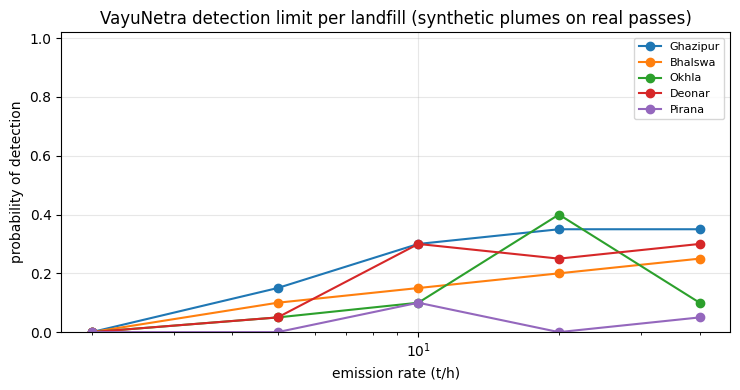

    site  detect_limit_tph  confirm_limit_tph
Ghazipur               NaN                NaN
 Bhalswa               NaN                NaN
   Okhla               NaN                NaN
  Deonar               NaN                NaN
  Pirana               NaN                NaN


In [31]:
RATES = [2000, 5000, 10000, 20000, 40000]; N_PER = int(os.environ.get("VAYU_N_PER", 20))
def limit_at(qs, pods, level=0.5):
    if pods[0] >= level: return qs[0]
    for (q1, p1), (q2, p2) in zip(zip(qs, pods), zip(qs[1:], pods[1:])):
        if p1 < level <= p2: return math.exp(math.log(q1) + (level - p1) / (p2 - p1) * (math.log(q2) - math.log(q1)))
    return float("nan")
SENS = {}
for site, (la, lo, el, _) in SITES.items():
    P = PASSES[site]; clean = clean_passes(site, P)
    if not clean: continue
    det, conf = [], []
    for q in tqdm(RATES, desc=f"sensitivity {site}", leave=False):
        hits = hits_c = 0
        for j in range(N_PER):
            rs = np.random.default_rng(1000 * j + q); k = clean[j % len(clean)]; r = P.iloc[k]; th = rs.uniform(0, 2 * np.pi); u = rs.uniform(2, 5)
            enh = gaussian_plume_ppb(q, u, th, (CHIP / 2 + rs.uniform(-30, 30), CHIP / 2 + rs.uniform(-30, 30)), el)
            o, _, _ = run_scene(inject(r.chip, enh, r.sat, r.sza, r.vza), refs_for(P, k), r.sza, r.vza, r.sat, el, int(r.t), la, lo, wind=(u * math.cos(th), u * math.sin(th)))
            hits += o["detected"]; hits_c += o["tier"] in ("T1", "T2")
        det.append(hits / N_PER); conf.append(hits_c / N_PER)
    SENS[site] = dict(pod=det, pod_confirmed=conf, limit_kgph=limit_at(RATES, det), limit_confirmed_kgph=limit_at(RATES, conf))
SUMMARY["detect_limit_tph"] = SUMMARY.site.map(lambda s: SENS.get(s, {}).get("limit_kgph", np.nan) / 1000)
SUMMARY["confirm_limit_tph"] = SUMMARY.site.map(lambda s: SENS.get(s, {}).get("limit_confirmed_kgph", np.nan) / 1000)
fig, ax = plt.subplots(figsize=(7.5, 4))
for s, d in SENS.items(): ax.plot(np.array(RATES) / 1000, d["pod"], "o-", label=s)
ax.set_xscale("log"); ax.set_xlabel("emission rate (t/h)"); ax.set_ylabel("probability of detection"); ax.set_ylim(0, 1.02); ax.grid(alpha=.3); ax.legend(fontsize=8)
ax.set_title("VayuNetra detection limit per landfill (synthetic plumes on real passes)"); plt.tight_layout(); plt.savefig(OUT / "sensitivity.png", dpi=140); plt.show()
print(SUMMARY[["site", "detect_limit_tph", "confirm_limit_tph"]].round(1).to_string(index=False))

**Cell 11 — Quantify emissions with uncertainty.** For every T1/T2 event: Monte Carlo over wind error, calibration error and mask threshold gives a median kg/h and a 68% range.
Site totals use a conservative minimum: emission only on days with a confirmed plume, zero on all other days.

In [32]:
def quantify_event(site, date, n=300, seed=0):
    la, lo, el, _ = SITES[site]; P = PASSES[site]; ev = EVENTS[(site, date)]; k = ev["k"]; r = P.iloc[k]
    if not np.isfinite(ev["u"]) or math.hypot(ev["u"], ev["v"]) < 1.5: return dict(q_med=np.nan, q_lo=np.nan, q_hi=np.nan)   # IME unreliable in calm air
    u10 = math.hypot(ev["u"], ev["v"]); key, amf = lut_key("S2" + str(r.sat)[-1]), amf_of(r.sza, r.vza)
    imes = [ime_kg(ev["m"], binary_dilation(ev["prob"] > t, iterations=2), key, amf, el) for t in (0.4, 0.5, 0.6)]
    rs = np.random.default_rng(seed); qs = []
    for _ in range(n):
        ime, L = imes[rs.integers(3)]
        if L <= 0: continue
        uu = max(0.5, u10 * (1 + rs.normal(0, ASSUME["wind_rel_unc"]))); cal = 1 + rs.normal(0, ASSUME["calib_rel_unc"])
        qs.append(3600 * (A_CAL * uu + B_CAL) * cal * ime / L)
    qs = np.array(qs); return dict(q_med=float(np.median(qs)), q_lo=float(np.percentile(qs, 16)), q_hi=float(np.percentile(qs, 84))) if len(qs) else dict(q_med=np.nan, q_lo=np.nan, q_hi=np.nan)

CONF = FLAGS[FLAGS.tier.isin(["T1", "T2"])].copy()
if len(CONF):
    CONF = pd.concat([CONF.reset_index(drop=True), pd.DataFrame([quantify_event(r.site, r.date) for r in CONF.itertuples()])], axis=1)
CONF.to_csv(OUT / "confirmed_events.csv", index=False)
def annual(site):
    s = SUMMARY.set_index("site").loc[site]; ev = CONF[CONF.site == site] if len(CONF) else CONF
    use = ev[ev.tier.isin(["T1", "T2"] if INCLUDE_T2_IN_ANNUAL else ["T1"])] if len(ev) else ev
    if not len(use) or not s.passes: return dict(min_mean_kgph=0.0, tch4_yr=0.0, tco2e100_yr=0.0, tco2e20_yr=0.0)
    mean_kgph = len(use) / s.passes * float(np.nanmedian(use.q_med))
    t = mean_kgph * 8.76                                                      # kg/h → t/yr
    return dict(min_mean_kgph=mean_kgph, tch4_yr=t, tco2e100_yr=t * ASSUME["gwp100"], tco2e20_yr=t * ASSUME["gwp20"])
SUMMARY = SUMMARY.drop(columns=[c for c in ["min_mean_kgph", "tch4_yr", "tco2e100_yr", "tco2e20_yr"] if c in SUMMARY])   # safe re-run
SUMMARY = pd.concat([SUMMARY, pd.DataFrame([annual(s) for s in SUMMARY.site])], axis=1); SUMMARY.to_csv(OUT / "site_summary.csv", index=False)
print((CONF[["site", "date", "tier", "q_med", "q_lo", "q_hi", "u10"]].round(0).to_string(index=False) if len(CONF) else "no T1/T2 events"))
print("\n" + SUMMARY[["site", "T1", "T2", "min_mean_kgph", "tco2e100_yr"]].round(0).to_string(index=False))

   site       date tier   q_med    q_lo    q_hi  u10
 Deonar 2025-01-06   T1 20183.0 15054.0 24974.0  5.0
  Okhla 2024-11-29   T2     NaN     NaN     NaN  1.0
Bhalswa 2025-05-18   T2 19146.0 14611.0 23245.0  3.0

    site  T1  T2  min_mean_kgph  tco2e100_yr
Ghazipur   0   0            0.0          0.0
 Bhalswa   0   1            0.0          0.0
   Okhla   0   1            0.0          0.0
  Deonar   1   0          301.0      71249.0
  Pirana   0   0            0.0          0.0


In [34]:
# Cell 11b — Upper bound on persistent emission per site
from scipy.stats import binom
def persistent_bound(site, alpha=0.05):
    s = SUMMARY.set_index("site").loc[site]; d = SENS.get(site)
    n, k = int(s["passes"]), int(s["flags"])
    if d is None or n == 0: return np.nan
    for q, p in zip(RATES, d["pod"]):
        if p > 0 and binom.cdf(k, n, p) < alpha: return q / 1000      # too few flags for a steady emitter at q
    return np.nan
SUMMARY["persistent_upper_tph"] = [persistent_bound(s) for s in SUMMARY["site"]]
print(SUMMARY[["site", "passes", "flags", "T1", "T2", "persistent_upper_tph"]].to_string(index=False))
print("reading: a steady emitter at or above persistent_upper_tph would have produced significantly more flags than observed (p<0.05).")

    site  passes  flags  T1  T2  persistent_upper_tph
Ghazipur      69      3   0   0                   5.0
 Bhalswa      70      2   0   1                   5.0
   Okhla      70      5   0   1                  20.0
  Deonar      67      3   1   0                  10.0
  Pirana      64      1   0   0                  10.0
reading: a steady emitter at or above persistent_upper_tph would have produced significantly more flags than observed (p<0.05).


**Cell 12 — Action plan: how to fix each site.** Converts evidence into decisions: confirm → capture → use the gas, with avoided CO₂e, electricity potential and carbon value from the editable assumptions.
Sites with only fire-like surface events get a fire-management plan; sites with nothing detected get their detection limit and a survey recommendation.

In [35]:
def action_plan(s):
    a = ASSUME; acts = []; econ = {}
    if s.T1 > 0 or s.T2 > 0:
        status = "PRIORITY — methane plume evidence" if s.T1 > 0 else "WATCH — probable plume, needs confirmation"
        acts.append("Confirm within 2–4 weeks: task a hyperspectral satellite (EMIT / EnMAP / PRISMA / Tanager) or fly an OGI-camera drone survey over the flagged area.")
        if s.min_mean_kgph > 0:
            cap = s.min_mean_kgph * a["capture_eff"]                                            # kg/h captured
            avoided = cap * 8.76 * a["flare_destruction"] * a["gwp100"]                         # tCO2e/yr
            mwe = cap * a["ch4_lhv_mj_per_kg"] / 3600 * a["engine_eff"]                        # MW electric
            mwh = mwe * 8760; inr = mwh * 1000 * a["power_price_inr_per_kwh"]; usd = avoided * a["carbon_price_usd_per_t"]
            econ = dict(captured_kgph=cap, avoided_tco2e_yr=avoided, power_mwe=mwe, power_mwh_yr=mwh, power_value_inr_yr=inr, carbon_value_usd_yr=usd)
            acts.append(f"Install landfill-gas collection (vertical wells + header) on the flagged cell; at {a['capture_eff']:.0%} capture this avoids ≈{avoided:,.0f} t CO₂e/yr (minimum estimate).")
            acts.append(f"Use the gas: ≈{mwe:.1f} MW electric ({mwh:,.0f} MWh/yr, ≈₹{inr/1e7:,.1f} crore/yr at ₹{a['power_price_inr_per_kwh']}/kWh); flare whatever the engine can't take.")
            acts.append(f"Register the avoided emissions for carbon credits: ≈${usd:,.0f}/yr at ${a['carbon_price_usd_per_t']}/t.")
        acts.append("Interim: cover exposed waste and apply a biocover / compost layer on side slopes to oxidise methane; repair cracks and leachate seeps.")
    elif s.flags > 0:
        status = "SURFACE ACTIVITY — no methane confirmed"
        acts.append(f"{s.flags} landfill flags were rejected by the physics gate as surface change ({s.burn_like} burn/smoke-like).")
        if s.burn_like: acts.append("Fire management: daily soil cover on active faces, thermal monitoring, water/foam readiness; burn-like events are themselves an alert.")
        acts.append("Re-scan monthly; re-survey with hyperspectral data once a year.")
    else:
        status = "NO LARGE EVENTS SEEN"
    lim = s.detect_limit_tph
    acts.append(f"Satellite sensitivity here: events above ≈{lim:.0f} t/h would be seen ~50% of the time; smaller, steady emissions need hyperspectral or ground survey."
                if np.isfinite(lim) else "Satellite sensitivity here: no plume size up to 40 t/h reached 50% detection — screening relies on hyperspectral / ground survey.")
    acts.append("Long term: continue legacy-waste bio-mining / remediation and divert organics (composting, biomethanation) so less methane is generated.")
    return status, acts, econ
PLANS = {s.site: action_plan(s) for s in SUMMARY.itertuples()}
for site, (status, acts, econ) in PLANS.items():
    print(f"\n■ {site}: {status}"); [print("  -", a_) for a_ in acts]


■ Ghazipur: SURFACE ACTIVITY — no methane confirmed
  - 3 landfill flags were rejected by the physics gate as surface change (2 burn/smoke-like).
  - Fire management: daily soil cover on active faces, thermal monitoring, water/foam readiness; burn-like events are themselves an alert.
  - Re-scan monthly; re-survey with hyperspectral data once a year.
  - Satellite sensitivity here: no plume size up to 40 t/h reached 50% detection — screening relies on hyperspectral / ground survey.
  - Long term: continue legacy-waste bio-mining / remediation and divert organics (composting, biomethanation) so less methane is generated.

■ Bhalswa: WATCH — probable plume, needs confirmation
  - Confirm within 2–4 weeks: task a hyperspectral satellite (EMIT / EnMAP / PRISMA / Tanager) or fly an OGI-camera drone survey over the flagged area.
  - Interim: cover exposed waste and apply a biocover / compost layer on side slopes to oxidise methane; repair cracks and leachate seeps.
  - Satellite sensitivity

**Cell 13 — Site dossiers (HTML).** One self-contained page per landfill: verdict, evidence images with wind, time series, detection limit, emission estimate and the action plan, plus an index page.
These are what you hand to a municipal corporation, pollution control board or carbon developer.

In [36]:
def fig_b64(fig):
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=110, bbox_inches="tight"); plt.close(fig); return base64.b64encode(buf.getvalue()).decode()
def evidence_fig(site, date, row):
    ev = EVENTS[(site, date)]; img = np.clip(np.moveaxis(ev["rgb"], 0, -1) * 3.5, 0, 1); c0 = CHIP / 2
    fig, ax = plt.subplots(1, 3, figsize=(11, 3.7))
    ax[0].imshow(img); ax[0].plot(c0, c0, "c+", ms=12); ax[0].set_title(f"{site} {date} (true colour)")
    ax[1].imshow(ev["m"], cmap="RdBu_r", vmin=-0.05, vmax=0.05); ax[1].set_title("methane signal (MBMP)")
    ax[2].imshow(img); ax[2].imshow(np.ma.masked_less(ev["prob"], 0.5), cmap="autumn", alpha=0.6)
    if np.isfinite(ev["u"]):
        sp = math.hypot(ev["u"], ev["v"]) + 1e-9; ax[2].arrow(20, 20, 25 * ev["u"] / sp, -25 * ev["v"] / sp, color="cyan", width=1.5, head_width=6)
    ax[2].set_title(f"VayuNetra {row['tier']} | " + (f"{row['q_kgph']/1000:.1f} t/h" if np.isfinite(row["q_kgph"]) else "rate n/a"))
    for a_ in ax: a_.axis("off")
    return fig_b64(fig)
def timeline_fig(site):
    L = SCAN[SCAN.site == site].sort_values("date"); fig, ax = plt.subplots(figsize=(10, 2.6))
    ax.plot(pd.to_datetime(L.date), L.scene_score, ".", c="0.6", label="all passes")
    for t_, c_ in [("T3", "tab:orange"), ("T2", "tab:purple"), ("T1", "tab:red")]:
        s_ = L[L.tier == t_]; ax.plot(pd.to_datetime(s_.date), s_.scene_score, "o", c=c_, label=t_) if len(s_) else None
    ax.axhline(THR, ls="--", c="k", lw=.8); ax.set_ylabel("scene score"); ax.set_ylim(0, 1); ax.legend(fontsize=7, ncol=4); ax.grid(alpha=.3)
    return fig_b64(fig)
CSS = """body{font-family:system-ui,Segoe UI,Arial;margin:24px;max-width:1100px;color:#1d2433}h1{margin:0}h2{border-bottom:2px solid #e3e7ef;padding-bottom:4px}
.badge{display:inline-block;padding:4px 10px;border-radius:12px;font-weight:600;color:#fff}.P{background:#c0392b}.W{background:#8e44ad}.S{background:#d68910}.N{background:#2e7d32}
table{border-collapse:collapse;font-size:13px}td,th{border:1px solid #e3e7ef;padding:4px 8px;text-align:left}img{max-width:100%}.small{color:#5b6475;font-size:12px}"""
def badge(status): return {"P": "P", "W": "W", "S": "S"}.get(status[0], "N")
def dossier(site):
    s = SUMMARY.set_index("site").loc[site]; status, acts, econ = PLANS[site]; la, lo, el, city = SITES[site]
    L = SCAN[(SCAN.site == site) & SCAN.detected].sort_values(["tier", "scene_score"], ascending=[True, False])
    imgs = "".join(f'<img src="data:image/png;base64,{evidence_fig(site, r.date, r._asdict())}"><p class="small">{r.date}: tier {r.tier} {r.surface_kind} · '
                   f'dB12 {r.dB12:+.3f}, dB11 {r.dB11:+.3f}, visible/NIR {r.dVisNIR:.3f} · axis vs wind {r.axis_vs_wind}°</p>' for r in L.head(4).itertuples())
    ev_tab = (CONF[CONF.site == site][["date", "tier", "q_med", "q_lo", "q_hi", "u10"]].round(0).to_html(index=False) if len(CONF) and (CONF.site == site).any() else "<p>No T1/T2 events.</p>")
    econ_tab = pd.Series(econ).round(1).to_frame("value").to_html() if econ else ""
    html = f"""<html><head><meta charset="utf-8"><title>VayuNetra — {site}</title><style>{CSS}</style></head><body>
<h1>VayuNetra site dossier — {site}, {city}</h1><p class="small">{la:.4f}, {lo:.4f} · scan {START} → {END} · generated {time.strftime('%Y-%m-%d')}</p>
<p><span class="badge {badge(status)}">{status}</span></p>
<h2>Evidence</h2><table><tr><th>clear passes</th><th>flags</th><th>T1 methane-confident</th><th>T2 probable</th><th>T3 surface change</th><th>control flags</th><th>p vs control</th><th>detection limit (t/h)</th></tr>
<tr><td>{s.passes}</td><td>{s.flags}</td><td>{s.T1}</td><td>{s.T2}</td><td>{s.T3}</td><td>{s.control_flags}/{s.control_passes}</td><td>{s.p_vs_control:.3g}</td><td>{s.detect_limit_tph:.1f}</td></tr></table>
<img src="data:image/png;base64,{timeline_fig(site)}">{imgs}
<h2>Emissions</h2>{ev_tab}<p>Minimum time-averaged rate: <b>{s.min_mean_kgph:,.0f} kg/h</b> → <b>{s.tco2e100_yr:,.0f} t CO₂e/yr</b> (GWP100) · {s.tco2e20_yr:,.0f} t CO₂e/yr (GWP20).
<span class="small">Counts only {'T1+T2' if INCLUDE_T2_IN_ANNUAL else 'T1'} days; all other days assumed zero.</span></p>
<h2>Action plan</h2><ol>{''.join(f'<li>{a_}</li>' for a_ in acts)}</ol>{econ_tab}
<h2>Method & assumptions</h2><p class="small">Sentinel-2 L1C (harmonized) 2 km chips; VayuNetra U-Net (SSL4EO-S12 ResNet-50, fine-tuned on MethaneSET + synthetic plumes),
scene threshold {THR:.2f}; physics gate (B12-only dimming, wind alignment); IME emission rate with U_eff = {A_CAL:.3f}·U10 + {B_CAL:.3f}; ERA5-Land wind.
Assumptions: {', '.join(f'{k}={v}' for k, v in ASSUME.items())}. Satellite estimates are screening-grade and must be confirmed before enforcement or crediting.</p></body></html>"""
    path = OUT / f"dossier_{site.replace(' ', '_')}.html"; path.write_text(html, encoding="utf-8"); return path
DOSSIERS = {s: dossier(s) for s in SITES}
rows_html = "".join(f"<tr><td><a href='{DOSSIERS[r.site].name}'>{r.site}</a></td><td>{r.city}</td><td><span class='badge {badge(PLANS[r.site][0])}'>{PLANS[r.site][0]}</span></td>"
                    f"<td>{r.T1}</td><td>{r.T2}</td><td>{r.T3}</td><td>{r.detect_limit_tph:.1f}</td><td>{r.tco2e100_yr:,.0f}</td></tr>" for r in SUMMARY.itertuples())
(OUT / "index.html").write_text(f"""<html><head><meta charset="utf-8"><title>VayuNetra — Indian landfills</title><style>{CSS}</style></head><body>
<h1>VayuNetra — Indian landfill methane screening</h1><p class="small">{START} → {END} · control false-alarm rate {SCAN[SCAN.kind=='control'].detected.mean():.1%}
· <a href="vayunetra_map.html">map</a></p><table><tr><th>site</th><th>city</th><th>status</th><th>T1</th><th>T2</th><th>T3</th><th>detection limit t/h</th><th>min t CO₂e/yr</th></tr>{rows_html}</table>
<img src="data:image/png;base64,{base64.b64encode(open(OUT/'sensitivity.png','rb').read()).decode()}"></body></html>""", encoding="utf-8")
print("dossiers:", [p.name for p in DOSSIERS.values()], "+ index.html")

dossiers: ['dossier_Ghazipur.html', 'dossier_Bhalswa.html', 'dossier_Okhla.html', 'dossier_Deonar.html', 'dossier_Pirana.html'] + index.html


**Cell 14 — Confirmation tasking list.** Exports every T1/T2 event (location, overpass time, estimated rate) as CSV and GeoJSON for hyperspectral tasking or a drone/ground team.
This is the hand-off from the free Sentinel-2 screener to the expensive, precise confirmation tier.

In [37]:
task = CONF.copy() if len(CONF) else pd.DataFrame(columns=["site", "date", "tier", "lat", "lon", "q_med", "q_lo", "q_hi", "t_ms"])
if len(task):
    task["overpass_utc"] = pd.to_datetime(task.t_ms, unit="ms").dt.strftime("%Y-%m-%d %H:%M")
    task["request"] = np.where(task.tier == "T1", "confirm + quantify (hyperspectral tasking / OGI drone)", "confirm (hyperspectral or ground survey)")
task.to_csv(OUT / "tasking_list.csv", index=False)
gj = dict(type="FeatureCollection", features=[dict(type="Feature", geometry=dict(type="Point", coordinates=[float(r.lon), float(r.lat)]),
          properties=dict(site=r.site, date=str(r.date), tier=r.tier, rate_kgph=None if not np.isfinite(r.q_med) else round(float(r.q_med)),
                          rate_68=[None if not np.isfinite(r.q_lo) else round(float(r.q_lo)), None if not np.isfinite(r.q_hi) else round(float(r.q_hi))]))
          for r in task.itertuples()])
json.dump(gj, open(OUT / "tasking_list.geojson", "w"), indent=1)
print(f"tasking list: {len(task)} events →", (OUT / "tasking_list.csv").name, "+ .geojson")

tasking list: 3 events → tasking_list.csv + .geojson


**Cell 15 — Map.** One interactive map of all landfills coloured by status, with links to each dossier and the control points shown in grey.
Open `vayunetra_map.html` in a browser or embed it in the pitch demo.

In [38]:
try:
    import folium
    mp = folium.Map(location=[23.5, 78.5], zoom_start=5, tiles="CartoDB positron")
    colour = {"P": "red", "W": "purple", "S": "orange", "N": "green"}
    for r in SUMMARY.itertuples():
        st_ = PLANS[r.site][0]
        folium.CircleMarker([r.lat, r.lon], radius=9, color=colour[badge(st_)], fill=True, fill_opacity=.85,
                            popup=folium.Popup(f"<b>{r.site}</b> ({r.city})<br>{st_}<br>T1 {r.T1} · T2 {r.T2} · T3 {r.T3}<br>"
                                               f"limit {r.detect_limit_tph:.1f} t/h<br><a href='{DOSSIERS[r.site].name}' target='_blank'>dossier</a>", max_width=260)).add_to(mp)
    for n, (la, lo, _, _) in CONTROLS.items(): folium.CircleMarker([la, lo], radius=4, color="gray", fill=True, popup=n).add_to(mp)
    mp.save(str(OUT / "vayunetra_map.html")); print("map →", OUT / "vayunetra_map.html")
except Exception as e: print("map skipped:", repr(e)[:120])

map → vayunetra_ops/vayunetra_map.html


**Cell 16 — Monitoring mode.** Re-scans only passes newer than the last run, appends them to a history file and prints new T1/T2 alerts.
Run it monthly (or schedule it) to turn VayuNetra from a one-off study into a standing early-warning service.

In [39]:
HIST = OUT / "monitor_history.csv"
def monitor(lookback_days=45):
    hist = pd.read_csv(HIST, parse_dates=["date"]) if HIST.exists() else SCAN.assign(date=pd.to_datetime(SCAN.date))
    today = dt.date.today(); start = (today - dt.timedelta(days=lookback_days + REF_MAX_DAYS)).isoformat(); new = []
    for name, (la, lo, el, _) in {**SITES, **CONTROLS}.items():
        seen = hist[hist.site == name].date.max(); after = seen.date() if pd.notna(seen) else today - dt.timedelta(days=lookback_days)
        new += scan_site(name, la, lo, el, "control" if name.endswith(" control") else "landfill", start=start, end=today.isoformat(), target_after=after)
    new = pd.DataFrame(new)
    if len(new):
        hist = pd.concat([hist, new.assign(date=pd.to_datetime(new.date))], ignore_index=True); hist.to_csv(HIST, index=False)
        alerts = new[(new.kind == "landfill") & new.tier.isin(["T1", "T2"])]
        print(f"{len(new)} new passes | alerts: {len(alerts)}")
        if len(alerts): print(alerts[["site", "date", "tier", "q_kgph", "scene_score"]].to_string(index=False))
    else: print("no new passes since last run")
    return new
if not HIST.exists(): SCAN.to_csv(HIST, index=False)
print("monitor(lookback_days=45) ready — run it whenever new Sentinel-2 passes arrive")

monitor(lookback_days=45) ready — run it whenever new Sentinel-2 passes arrive


**Cell 17 — Pack the outputs.** Zips dossiers, index, map, tasking list, CSVs and figures (not the cached chips) and gives a download link.
This is the deliverable bundle for the pitch and for any agency you share results with.

In [40]:
# Cell 7b — Calibrate the detection threshold on the 334 Indian control scenes (target ≈1% false alarms)
ctrl = SCAN[SCAN.kind == "control"].scene_score; land = SCAN[SCAN.kind == "landfill"].scene_score
print("control score quantiles:", {q: round(float(ctrl.quantile(q)), 3) for q in (0.9, 0.95, 0.98, 0.99, 1.0)})
THR_INDIA = float(max(0.5, ctrl.quantile(0.99)))
print(f"model-card threshold {CARD['scene_threshold']:.3f} → India-calibrated {THR_INDIA:.3f} | "
      f"landfill passes above it: {(land > THR_INDIA).sum()} (was {(land > CARD['scene_threshold']).sum()}) | controls above: {(ctrl > THR_INDIA).sum()}")
THR = THR_INDIA            # re-run Cells 7 → 17: more candidates enter, the physics gate decides which are methane

control score quantiles: {0.9: 0.518, 0.95: 0.602, 0.98: 0.717, 0.99: 0.793, 1.0: 0.814}
model-card threshold 0.844 → India-calibrated 0.793 | landfill passes above it: 31 (was 14) | controls above: 4


In [41]:
zip_path = Path(f"vayunetra_ops_{time.strftime('%Y%m%d_%H%M')}.zip").resolve()
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT.rglob("*"):
        if p.is_file() and "chips" not in p.parts and "model" not in p.parts: z.write(p, arcname=str(Path("vayunetra_ops") / p.relative_to(OUT)))
print(f"{zip_path.name}: {zip_path.stat().st_size/1e6:.1f} MB")
try:
    from google.colab import files as _c; _c.download(str(zip_path))
except ImportError:
    try:
        from IPython.display import FileLink, display; display(FileLink(os.path.relpath(zip_path)))
    except Exception: pass

vayunetra_ops_20261001_1656.zip: 4.5 MB


/workspace/vayunetra_ops_20261001_1656.zip